<a href="https://colab.research.google.com/github/J-J-Allison/DeepLearning_PATHMNIST_Medical/blob/main/PathMNIST_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PathMNIST — Colorectal Cancer Histology Classification
# **Final Project — Deep Learning 2025–2026**

## Part 0 — Setup

In [1]:
!pip install medmnist tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import medmnist
from medmnist import PathMNIST
import time, copy, math
from medmnist import INFO

# Metadata
label_map   = INFO["pathmnist"]["label"]
CLASS_NAMES = [label_map[str(i)] for i in range(9)]

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device — auto-select GPU on Colab
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}  "
          f"({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)")
else:
    print("No GPU found — running on CPU (training will be slow)")
print(f"Using: {DEVICE}")

# Data
train_dataset = PathMNIST(split="train", download=True, size=28)
val_dataset   = PathMNIST(split="val",   download=True, size=28)
test_dataset  = PathMNIST(split="test",  download=True, size=28)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].size}")
print(f"Label shape: {train_dataset[0][1].shape}")
print(f"Classes: {CLASS_NAMES}")

GPU: NVIDIA L4  (22.0 GB)
Using: cuda


100%|██████████| 206M/206M [00:12<00:00, 16.3MB/s]


Train: 89996 | Val: 10004 | Test: 7180
Image shape: (28, 28)
Label shape: (1,)
Classes: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']


### Checkpoint System (Google Drive)
Run this cell once to mount Drive and set up save/load helpers. All training sections below will skip automatically if a checkpoint exists.

In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = "/content/drive/MyDrive/pathmnist_checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CKPT_DIR}")

def save_ckpt(name, **kwargs):
    path = f"{CKPT_DIR}/{name}.pt"
    torch.save(kwargs, path)
    print(f"💾 Saved checkpoint: {name} ({os.path.getsize(path)/1e6:.1f} MB)")

def load_ckpt(name):
    path = f"{CKPT_DIR}/{name}.pt"
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {name}")
        return torch.load(path, map_location=DEVICE, weights_only=False)
    print(f"ℹ️ No checkpoint found for {name} — will train from scratch")
    return None

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/pathmnist_checkpoints


In [4]:
import sys

LOG_PATH = f"{CKPT_DIR}/training_log.txt"
class TeeLogger:
    def __init__(self, logfile, stream):
        self.logfile = open(logfile, "a")
        self.stream = stream
        self.encoding = getattr(stream, 'encoding', 'utf-8')
    def write(self, msg):
        self.stream.write(msg)
        self.logfile.write(msg)
    def flush(self):
        self.stream.flush()
        self.logfile.flush()
    def __getattr__(self, name):
        return getattr(self.stream, name)

sys.stdout = TeeLogger(LOG_PATH, sys.stdout)
print(f"Logging to {LOG_PATH}")

Logging to /content/drive/MyDrive/pathmnist_checkpoints/training_log.txt


### Part 1 — Data Exploration

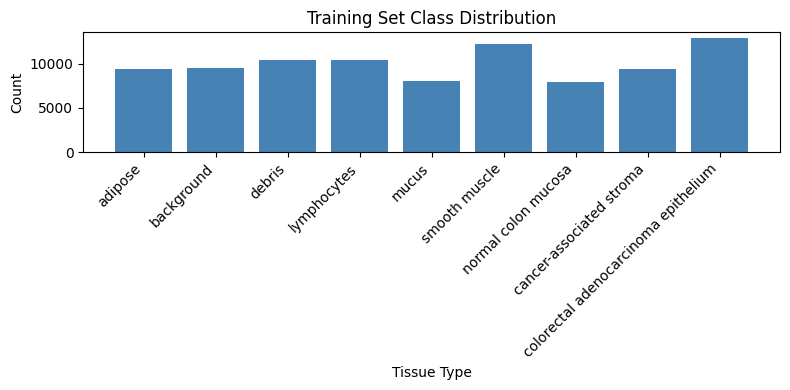

In [5]:
# Class distribution

train_labels = np.array([y.item() for _, y in train_dataset])

fig, ax = plt.subplots(figsize=(8, 4))
counts = [np.sum(train_labels == c) for c in range(9)]
ax.bar(range(9), counts, color="steelblue")
ax.set_xticks(range(9))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_xlabel("Tissue Type")
ax.set_ylabel("Count")
ax.set_title("Training Set Class Distribution")
plt.tight_layout()
plt.show()

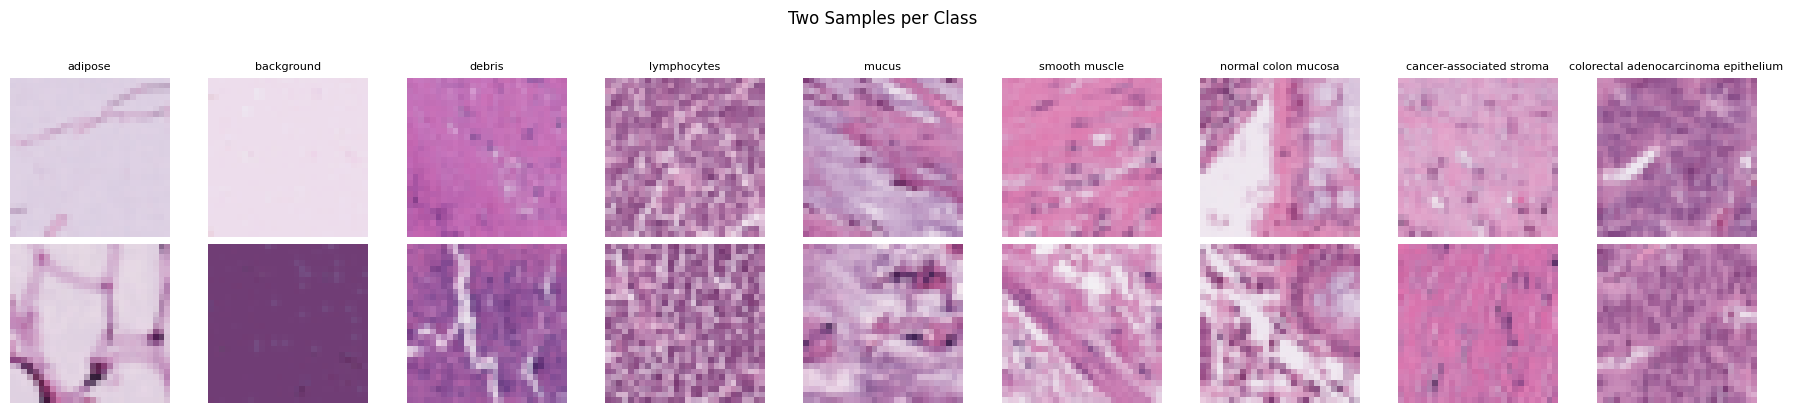

In [6]:
# Sample images per class
fig, axes = plt.subplots(2, 9, figsize=(18, 4))
for c in range(9):
    idxs = np.where(train_labels == c)[0][:2]
    for row, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[row, c].imshow(img)
        axes[row, c].axis("off")
        if row == 0:
            axes[row, c].set_title(CLASS_NAMES[c], fontsize=8)
fig.suptitle("Two Samples per Class", y=1.02)
plt.tight_layout()
plt.show()

Q1.1 — Look at several images from the Debris class and several from Background. Describe in your own words what visual differences you observe between them. Include at least one specific observation about color or texture.

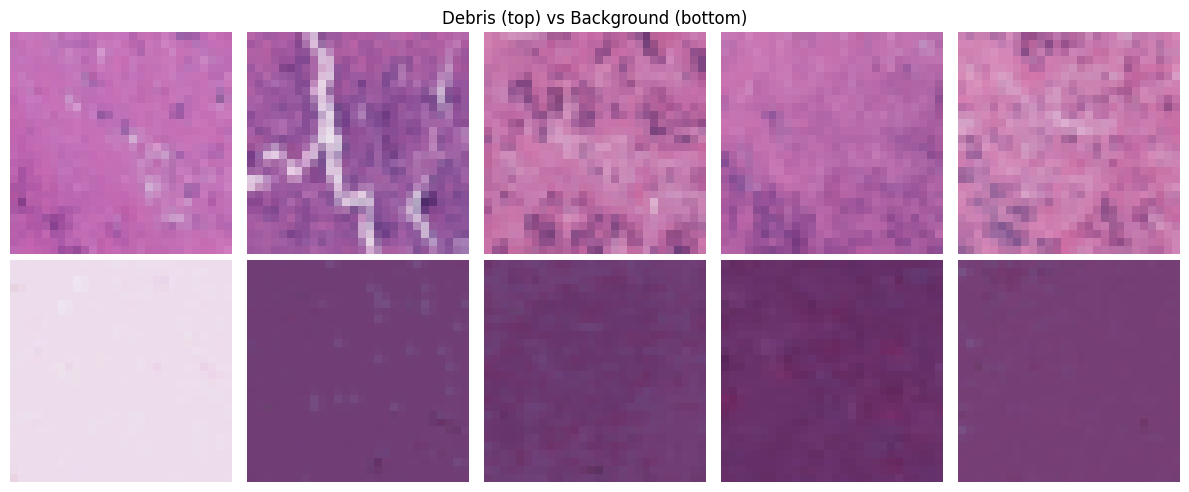

In [7]:
#Q1.1 — Debris vs Background
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, c in enumerate([2, 1]):  # Debris=2, Background=1
    idxs = np.where(train_labels == c)[0][:5]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(CLASS_NAMES[c], fontsize=10)
axes[0, 2].set_title("Debris (top) vs Background (bottom)")
plt.tight_layout()
plt.show()

A:
Background patches are mostly homogeneous — pale, uniform color with little structural detail. Debris patches show mixed colors (pink, purple, white fragments) and irregular, fragmented textures with no clear cellular organization.

Q1.2 — Pick any single image from the training set and report its pixel intensity statistics: mean and standard deviation per channel (R, G, B). Are these values close to ImageNet statistics? Show the computation.

In [8]:
from torchvision.models import ResNet50_Weights

rng_idx = np.random.randint(len(train_dataset))
img_pil, label = train_dataset[rng_idx]
target_class = label.item()
print(f"Sample index: {rng_idx} | Label: {target_class} — {CLASS_NAMES[target_class]}\n")

img_np = np.array(img_pil, dtype=np.float32) / 255.0

t = ResNet50_Weights.DEFAULT.transforms()

for ch, name in enumerate(["R", "G", "B"]):
    print(f"{name}: mean={img_np[:,:,ch].mean():.4f} (ImageNet: {t.mean[ch]:.3f}) | "
          f"std={img_np[:,:,ch].std():.4f} (ImageNet: {t.std[ch]:.3f})")

Sample index: 15795 | Label: 1 — background

R: mean=0.5038 (ImageNet: 0.485) | std=0.0428 (ImageNet: 0.229)
G: mean=0.2817 (ImageNet: 0.456) | std=0.0282 (ImageNet: 0.224)
B: mean=0.4928 (ImageNet: 0.406) | std=0.0383 (ImageNet: 0.225)


A: Computation (sample index 15795, class: background, image 28×28 → N = 784 pixels per channel):

mean_R = (1 / 784) × Σ pixel_R(i,j) = 0.5038

std_R  = sqrt( (1 / 784) × Σ (pixel_R(i,j) − 0.5038)² ) = 0.0428

mean_G = (1 / 784) × Σ pixel_G(i,j) = 0.2817

std_G  = sqrt( (1 / 784) × Σ (pixel_G(i,j) − 0.2817)² ) = 0.0282

mean_B = (1 / 784) × Σ pixel_B(i,j) = 0.4928

std_B  = sqrt( (1 / 784) × Σ (pixel_B(i,j) − 0.4928)² ) = 0.0383

ImageNet reference — mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]

The mean and standard deviation values differ from ImageNet across all three channels — for example, R and G means sit around 0.50 and 0.28 respectively, compared to ImageNet's 0.40–0.49, suggesting these images are on average brighter. The standard deviation is also lower, indicating more homogeneous color compared to a typical ImageNet image.

### Part 2 — Dense Network Baseline (MLP)

Build a multi-layer perceptron to establish a baseline.

• At least 2 hidden layers with dropout.
• Reach ≥ 55% test accuracy.
• Plot training curves (loss and accuracy for train and validation).
• Show the confusion matrix on the test set.

In [9]:
# Transforms: flatten 28x28x3 → 2352
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_mlp = PathMNIST(split="train", transform=transform_mlp, download=True, size=28)
val_mlp   = PathMNIST(split="val",   transform=transform_mlp, download=True, size=28)
test_mlp  = PathMNIST(split="test",  transform=transform_mlp, download=True, size=28)

train_loader_mlp = DataLoader(train_mlp, batch_size=256, shuffle=True)
val_loader_mlp   = DataLoader(val_mlp,   batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_mlp,  batch_size=256, shuffle=False)

In [10]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3*28*28, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),     nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 9)
        )
    def forward(self, x):
        return self.net(x)

mlp = MLP().to(DEVICE)
print(f"MLP parameters: {sum(p.numel() for p in mlp.parameters() if p.requires_grad):,}")

MLP parameters: 1,370,121


In [11]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=30, label="Model"):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # Val
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
                out = model(X)
                loss = criterion(out, y)
                running_loss += loss.item() * X.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        if scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if epoch == 1 or epoch == 10 or epoch == epochs:
            print(f"[{label}] Epoch {epoch}/{epochs} — "
                  f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return history

In [12]:
def plot_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Val")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title(f"{title} — Loss")
    ax1.legend()
    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Val")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title(f"{title} — Accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()

In [13]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            out = model(X)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    acc = correct / total
    return acc, np.array(all_preds), np.array(all_labels)

def plot_confusion(preds, labels, title):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

In [14]:
# MLP Training (with checkpoint)
ckpt = load_ckpt("mlp")
if ckpt:
    mlp = MLP().to(DEVICE)
    mlp.load_state_dict(ckpt["state_dict"])
    history_mlp = ckpt["history"]
    acc_mlp = ckpt["acc"]
    preds_mlp = ckpt["preds"]
    labels_mlp = ckpt["labels"]
    print(f"MLP Test Accuracy (from checkpoint): {acc_mlp:.4f}")
else:
    criterion = nn.CrossEntropyLoss()
    optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3)
    history_mlp = train_model(mlp, train_loader_mlp, val_loader_mlp,
                              criterion, optimizer_mlp, epochs=30, label="MLP")
    acc_mlp, preds_mlp, labels_mlp = evaluate(mlp, test_loader_mlp)
    print(f"MLP Test Accuracy: {acc_mlp:.4f}")
    save_ckpt("mlp", state_dict=mlp.state_dict(), history=history_mlp,
              acc=acc_mlp, preds=preds_mlp, labels=labels_mlp)

📂 Loading checkpoint: mlp
MLP Test Accuracy (from checkpoint): 0.6462


In [15]:
# Reconstruct MLP logs
for i in range(len(history_mlp["train_acc"])):
    if i == 0 or i == 9 or i == len(history_mlp["train_acc"]) - 1:
        print(f"[MLP] Epoch {i+1}/{len(history_mlp['train_acc'])} — "
              f"train_loss={history_mlp['train_loss'][i]:.4f} train_acc={history_mlp['train_acc'][i]:.4f} "
              f"val_loss={history_mlp['val_loss'][i]:.4f} val_acc={history_mlp['val_acc'][i]:.4f}")

[MLP] Epoch 1/30 — train_loss=1.5209 train_acc=0.4178 val_loss=1.2578 val_acc=0.5356
[MLP] Epoch 10/30 — train_loss=1.0657 train_acc=0.5965 val_loss=1.0010 val_acc=0.6228
[MLP] Epoch 30/30 — train_loss=0.8829 train_acc=0.6624 val_loss=1.3795 val_acc=0.5587


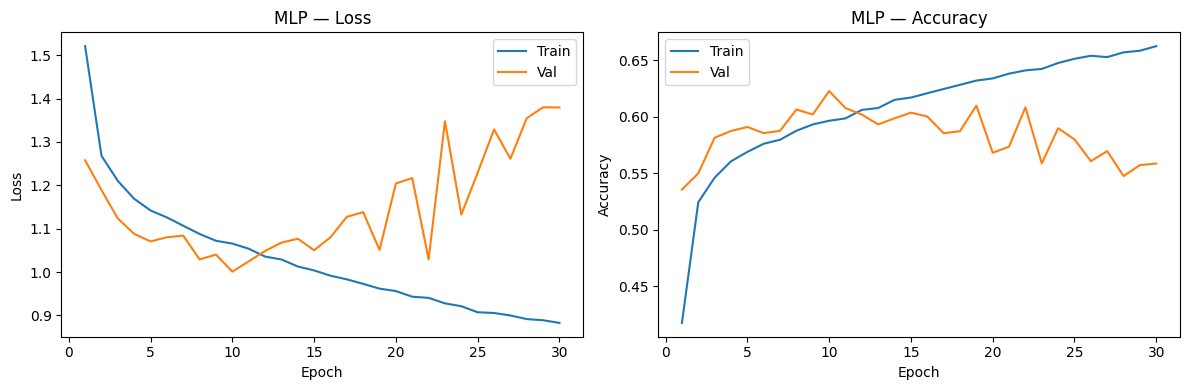

In [16]:
plot_curves(history_mlp, "MLP")

MLP Test Accuracy: 0.6462


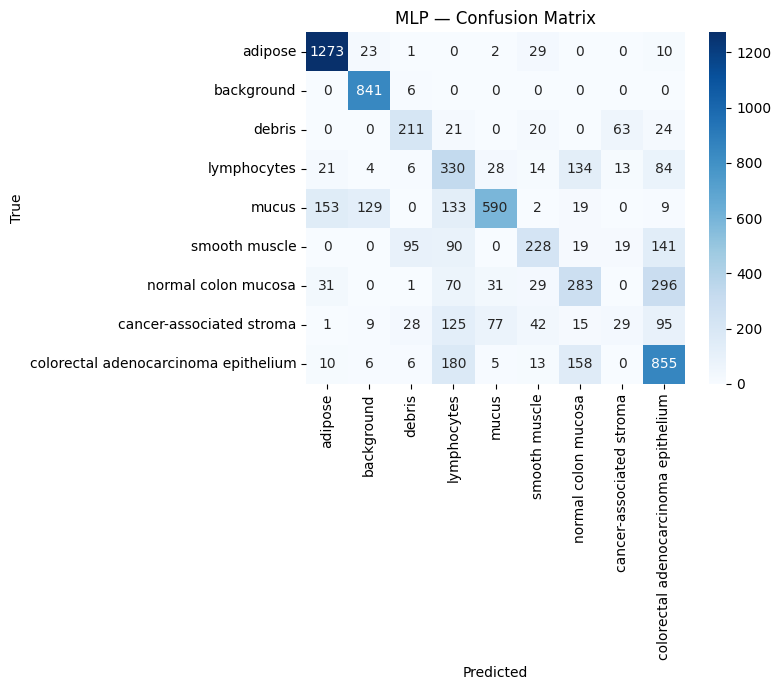

In [17]:
print(f"MLP Test Accuracy: {acc_mlp:.4f}")
cm_mlp = plot_confusion(preds_mlp, labels_mlp, "MLP — Confusion Matrix")

Q2.1 — Report your model's exact test accuracy and the exact validation loss at
epochs 1, 10, and at your final epoch. Do not round — copy the values from your
logs.


A:

[MLP] Epoch 1/30 — train_loss=1.5209 train_acc=0.4178 val_loss=1.2578 val_acc=0.5356

[MLP] Epoch 10/30 — train_loss=1.0657 train_acc=0.5965 val_loss=1.0010 val_acc=0.6228

[MLP] Epoch 30/30 — train_loss=0.8829 train_acc=0.6624 val_loss=1.3795 val_acc=0.5587

The validation loss decreased steadily from epoch 1 to epoch 10, then rose back up by the final epoch — suggesting the model begins to overfit after epoch 10, where it reaches its best generalisation before memorising the training data.

Q2.2 — Look at the confusion matrix. Identify the single cell (predicted class, true class)
with the highest number of misclassifications. Report the exact count and explain
why this confusion might occur by looking at example images from both classes.


A: The largest number : 296 images of normal colon mucosa missclassified as colorectal adenocarcinoma epithelium. They look very similar in the comparison of the images.

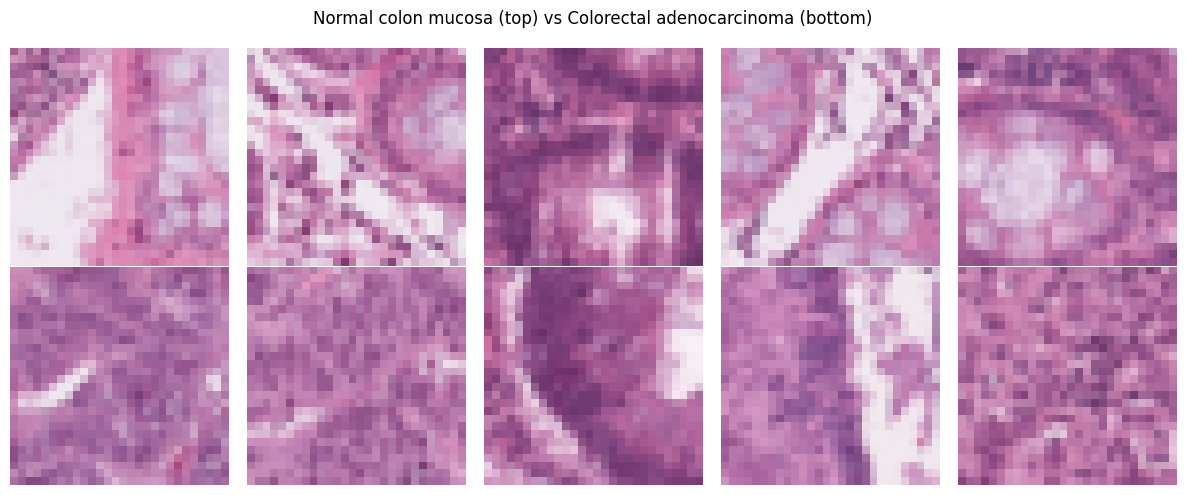

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, c in enumerate([6, 8]):  # 6=normal colon mucosa, 8=colorectal adenocarcinoma epithelium
    idxs = np.where(train_labels == c)[0][:5]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(CLASS_NAMES[c], fontsize=9)
plt.suptitle("Normal colon mucosa (top) vs Colorectal adenocarcinoma (bottom)")
plt.tight_layout()
plt.show()

#Part 3 : CNN from Scratch
Design and train a convolutional neural network with proper regularization.

• At least 3 convolutional blocks with batch normalization and dropout.

• Data augmentation with a justified choice of transformations.

• Reach ≥ 75% test accuracy.

• Compare results with vs. without augmentation (same model, same hyperparameters, two runs).

In [19]:
# Transforms

transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [20]:
#Dataloading

train_noaug = PathMNIST(split="train", transform=transform_base, download=True, size=28)
train_aug   = PathMNIST(split="train", transform=transform_aug,  download=True, size=28)
val_ds      = PathMNIST(split="val",   transform=transform_base, download=True, size=28)
test_ds     = PathMNIST(split="test",  transform=transform_base, download=True, size=28)

loader_train_noaug = DataLoader(train_noaug, batch_size=128, shuffle=True)
loader_train_aug   = DataLoader(train_aug,   batch_size=128, shuffle=True)
loader_val         = DataLoader(val_ds,      batch_size=128, shuffle=False)
loader_test        = DataLoader(test_ds,     batch_size=128, shuffle=False)

In [21]:
#CNN architecture

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 → 32, spatial 28 → 14
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2: 32 → 64, spatial 14 → 7
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3: 64 → 128, spatial 7 → 1
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 9)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Parameter count validation

cnn_check = CNN()
total_params = sum(p.numel() for p in cnn_check.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

# First conv layer: Conv2d(3, 32, kernel_size=3)
# Formula: (C_in × K × K + 1) × C_out = (3 × 3 × 3 + 1) × 32 = 896
first_conv = list(cnn_check.features.children())[0]
print(f"First conv (manual):  (3 × 3 × 3 + 1) × 32 = {(3*3*3+1)*32}")
print(f"First conv (model):   {sum(p.numel() for p in first_conv.parameters())}")
del cnn_check

Total trainable parameters: 289,065
First conv (manual):  (3 × 3 × 3 + 1) × 32 = 896
First conv (model):   896


In [22]:
#Training loop

def train_cnn(model, train_loader, val_loader, epochs=40):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        rl, c, t = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            rl += loss.item() * X.size(0)
            c += (out.argmax(1) == y).sum().item()
            t += y.size(0)
        history["train_loss"].append(rl / t)
        history["train_acc"].append(c / t)

        model.eval()
        rl, c, t = 0.0, 0, 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
                out = model(X)
                loss = criterion(out, y)
                rl += loss.item() * X.size(0)
                c += (out.argmax(1) == y).sum().item()
                t += y.size(0)
        history["val_loss"].append(rl / t)
        history["val_acc"].append(c / t)
        scheduler.step()

        gap = history["train_acc"][-1] - history["val_acc"][-1]
        print(f"Epoch {epoch:02d}/{epochs} — "
              f"train_acc={history['train_acc'][-1]:.4f}  "
              f"val_acc={history['val_acc'][-1]:.4f}  gap={gap:.4f}")

    return history

Q3.1 — Run your CNN without any augmentation for 40 epochs. At which epoch does
the gap between training accuracy and validation accuracy exceed 15 percentage points for
the first time? Report the exact epoch number and both accuracy values.

In [23]:
# CNN Training — No Augmentation + Augmentation (with checkpoint)

def get_test_acc(model, loader):
    model.eval()
    c, t = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            preds = model(X).argmax(1)
            c += (preds == y).sum().item()
            t += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return c / t, np.array(all_preds), np.array(all_labels)

ckpt = load_ckpt("cnn")
if ckpt:
    cnn_noaug = CNN().to(DEVICE); cnn_noaug.load_state_dict(ckpt["noaug_sd"])
    cnn_aug   = CNN().to(DEVICE); cnn_aug.load_state_dict(ckpt["aug_sd"])
    history_noaug = ckpt["history_noaug"]
    history_aug   = ckpt["history_aug"]
    acc_noaug     = ckpt["acc_noaug"]
    acc_aug       = ckpt["acc_aug"]
    preds_cnn     = ckpt["preds"]
    labels_cnn    = ckpt["labels"]
    print(f"CNN (no aug) Test Accuracy (from checkpoint): {acc_noaug:.4f}")
    print(f"CNN (aug)    Test Accuracy (from checkpoint): {acc_aug:.4f}")
else:
    # Train without Augmentation for 40 epochs
    cnn_noaug = CNN().to(DEVICE)
    history_noaug = train_cnn(cnn_noaug, loader_train_noaug, loader_val, epochs=40)

    # Train with Augmentation for 40 epochs
    cnn_aug = CNN().to(DEVICE)
    history_aug = train_cnn(cnn_aug, loader_train_aug, loader_val, epochs=40)

    acc_noaug, _, _ = get_test_acc(cnn_noaug, loader_test)
    acc_aug, preds_cnn, labels_cnn = get_test_acc(cnn_aug, loader_test)

    save_ckpt("cnn",
        noaug_sd=cnn_noaug.state_dict(), history_noaug=history_noaug, acc_noaug=acc_noaug,
        aug_sd=cnn_aug.state_dict(), history_aug=history_aug, acc_aug=acc_aug,
        preds=preds_cnn, labels=labels_cnn)

📂 Loading checkpoint: cnn
CNN (no aug) Test Accuracy (from checkpoint): 0.8631
CNN (aug)    Test Accuracy (from checkpoint): 0.8962


In [24]:
# Reconstruct CNN logs
for name, hist in [("CNN noaug", history_noaug), ("CNN aug", history_aug)]:
    print(f"\n=== {name} ===")
    for i in range(len(hist["train_acc"])):
        gap = hist["train_acc"][i] - hist["val_acc"][i]
        print(f"Epoch {i+1:02d}/40 — "
              f"train_acc={hist['train_acc'][i]:.4f}  "
              f"val_acc={hist['val_acc'][i]:.4f}  gap={gap:.4f}")


=== CNN noaug ===
Epoch 01/40 — train_acc=0.6863  val_acc=0.8100  gap=-0.1237
Epoch 02/40 — train_acc=0.7937  val_acc=0.8709  gap=-0.0772
Epoch 03/40 — train_acc=0.8318  val_acc=0.8745  gap=-0.0427
Epoch 04/40 — train_acc=0.8546  val_acc=0.8891  gap=-0.0346
Epoch 05/40 — train_acc=0.8715  val_acc=0.9033  gap=-0.0319
Epoch 06/40 — train_acc=0.8825  val_acc=0.9130  gap=-0.0306
Epoch 07/40 — train_acc=0.8923  val_acc=0.9302  gap=-0.0380
Epoch 08/40 — train_acc=0.8997  val_acc=0.9193  gap=-0.0197
Epoch 09/40 — train_acc=0.9052  val_acc=0.9310  gap=-0.0258
Epoch 10/40 — train_acc=0.9107  val_acc=0.9178  gap=-0.0071
Epoch 11/40 — train_acc=0.9150  val_acc=0.9366  gap=-0.0216
Epoch 12/40 — train_acc=0.9177  val_acc=0.9325  gap=-0.0148
Epoch 13/40 — train_acc=0.9207  val_acc=0.9139  gap=0.0067
Epoch 14/40 — train_acc=0.9234  val_acc=0.9525  gap=-0.0291
Epoch 15/40 — train_acc=0.9285  val_acc=0.9444  gap=-0.0159
Epoch 16/40 — train_acc=0.9403  val_acc=0.9608  gap=-0.0205
Epoch 17/40 — train_ac

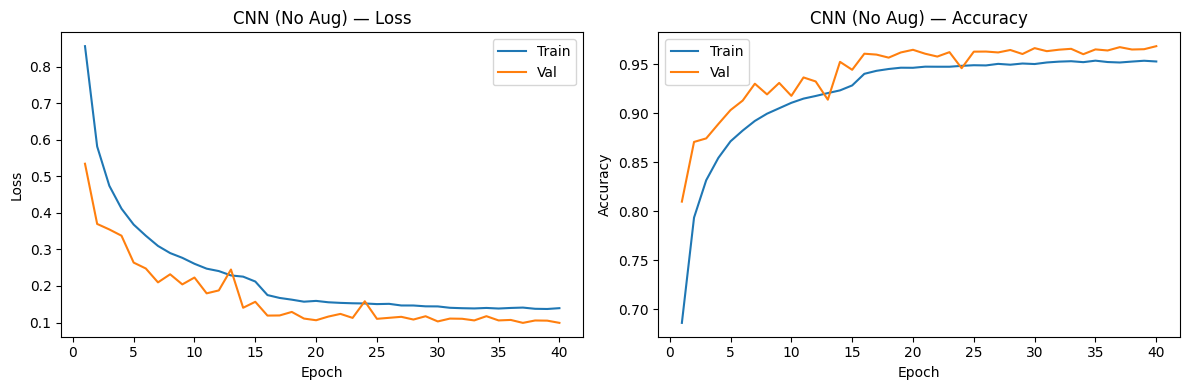

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, 41)

ax1.plot(epochs_range, history_noaug["train_loss"], label="Train")
ax1.plot(epochs_range, history_noaug["val_loss"],   label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("CNN (No Aug) — Loss"); ax1.legend()

ax2.plot(epochs_range, history_noaug["train_acc"], label="Train")
ax2.plot(epochs_range, history_noaug["val_acc"],   label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("CNN (No Aug) — Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

In [26]:
# First Epoch Where Train-Val Gap Exceeds 15pp

for i, (ta, va) in enumerate(zip(history_noaug["train_acc"], history_noaug["val_acc"])):
    if ta - va > 0.15:
        print(f"First >15pp gap at epoch {i+1}: train_acc={ta:.4f}, val_acc={va:.4f}")
        break
else:
    print("Gap never exceeded 15pp in 40 epochs.")

Gap never exceeded 15pp in 40 epochs.


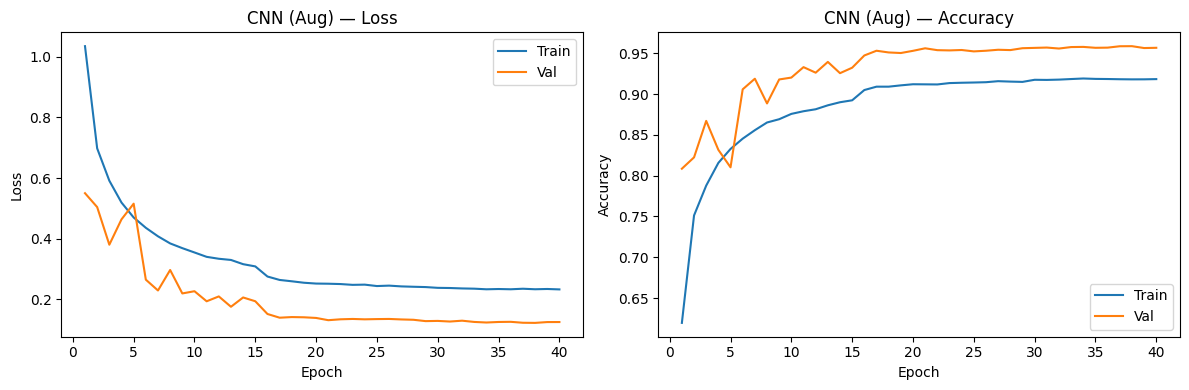

In [27]:
# Training Curves — With Augmentation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history_aug["train_loss"], label="Train")
ax1.plot(epochs_range, history_aug["val_loss"],   label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("CNN (Aug) — Loss"); ax1.legend()

ax2.plot(epochs_range, history_aug["train_acc"], label="Train")
ax2.plot(epochs_range, history_aug["val_acc"],   label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("CNN (Aug) — Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

Test accuracy WITHOUT augmentation: 0.8631
Test accuracy WITH    augmentation: 0.8962
Improvement: +0.0331


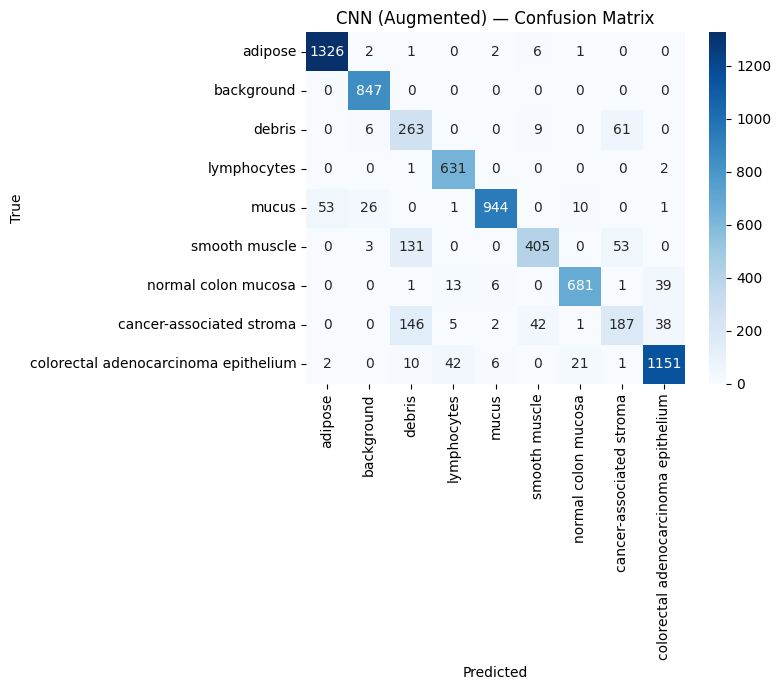

In [28]:
# Test Evaluation and Comparison

print(f"Test accuracy WITHOUT augmentation: {acc_noaug:.4f}")
print(f"Test accuracy WITH    augmentation: {acc_aug:.4f}")
print(f"Improvement: {acc_aug - acc_noaug:+.4f}")

# Confusion Matrix — Augmented CNN

cm = confusion_matrix(labels_cnn, preds_cnn)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("CNN (Augmented) — Confusion Matrix")
plt.tight_layout()
plt.show()

Q3.2 — Histology images have a property that natural photographs do not: they have no
canonical orientation (a tissue patch looks equally valid upside-down or mirrored). Name
one common augmentation that exploits this property and one augmentation from natural
image classification that would be harmful or meaningless for histology. Explain both
choices.

A: Augmentation Justification (WIP)

**Exploits no canonical orientation**: *RandomVerticalFlip*. A tissue patch under a microscope looks equally valid flipped — there's no "up," so this is free extra training data with zero distortion.

**Harmful for histology**: *ColorJitter* is not suitable. Unlike natural images, colors in histology carry precise biological meaning. Artificially altering them risks distorting essential diagnostic information and degrading the model’s performance.


Q3.3 Print the total number of trainable parameters in your CNN. Then, manually
compute the number of parameters in your first convolutional layer (show the formula and
calculation). Verify that it matches the model summary.

In [29]:
#A:
print(f"{'Layer':<45} {'Params':>10}")
print("-" * 57)
total = 0
for name, param in cnn_aug.named_parameters():
    print(f"{name:<45} {param.numel():>10,}")
    total += param.numel()
print("-" * 57)
print(f"{'TOTAL TRAINABLE PARAMETERS':<45} {total:>10,}")

Layer                                             Params
---------------------------------------------------------
features.0.weight                                    864
features.0.bias                                       32
features.1.weight                                     32
features.1.bias                                       32
features.3.weight                                  9,216
features.3.bias                                       32
features.4.weight                                     32
features.4.bias                                       32
features.8.weight                                 18,432
features.8.bias                                       64
features.9.weight                                     64
features.9.bias                                       64
features.11.weight                                36,864
features.11.bias                                      64
features.12.weight                                    64
features.12.bias              

In [30]:
# Q3.3 — Manual computation for the first convolutional layer
# Layer: Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
#
# Formula: params = (C_in × K_h × K_w + 1) × C_out
#                    ─────────────────   ─    ─────
#                    weights per filter  bias  num filters
#
# Weights: each filter has C_in × K × K = 3 × 3 × 3 = 27 values
# Bias:    one scalar per output channel                =  1
# Filters: C_out                                        = 32
#
# Total = (27 + 1) × 32 = 28 × 32 = 896

C_in, C_out, K = 3, 32, 3
manual_count = (C_in * K * K + 1) * C_out
print(f"\nManual calculation:")
print(f"  Weights per filter : {C_in} × {K} × {K} = {C_in * K * K}")
print(f"  + bias per filter  : 1")
print(f"  × number of filters: {C_out}")
print(f"  = ({C_in * K * K} + 1) × {C_out} = {manual_count}")

# Verify against model
first_conv = list(cnn_aug.features.children())[0]
model_count = sum(p.numel() for p in first_conv.parameters())
print(f"\nModel reports: {model_count}")
print(f"Match: {manual_count == model_count}")


Manual calculation:
  Weights per filter : 3 × 3 × 3 = 27
  + bias per filter  : 1
  × number of filters: 32
  = (27 + 1) × 32 = 896

Model reports: 896
Match: True


 # 4 Transfer Learning with ResNet-18
Fine-tune a pretrained ResNet-18 on PathMNIST.

• Use ImageNet-pretrained weights.

• Handle the input size mismatch appropriately.

• Reach ≥ 85% test accuracy.

• Run two experiments: (a) fine-tune only the classification head with all other layers frozen, (b) fine-tune the entire network. Report both results.

In [31]:
!pip install medmnist -q
from medmnist import PathMNIST

print("Downloading train..."); PathMNIST(split="train", download=True, size=224)
print("Downloading val...");   PathMNIST(split="val",   download=True, size=224)
print("Downloading test...");  PathMNIST(split="test",  download=True, size=224)
print("✅ All downloads complete.")

100%|██████████| 12.6G/12.6G [15:30<00:00, 13.6MB/s]


✅ All downloads complete.


In [32]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from medmnist import PathMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# 1. Device & global config
# ============================================================
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2
PIN_MEMORY  = torch.cuda.is_available()
BATCH_SIZE  = 512

EPOCHS_FROZEN = 15
EPOCHS_FULL   = 15

print(f"Using device: {DEVICE}")

Using device: cuda


In [33]:
# ============================================================
# Criterion
# ============================================================
criterion = nn.CrossEntropyLoss()

# ============================================================
# Transforms & Datasets (no download — already done)
# ============================================================
transform_resnet = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

train_resnet = PathMNIST(split="train", transform=transform_resnet, download=False, size=224)
val_resnet   = PathMNIST(split="val",   transform=transform_resnet, download=False, size=224)
test_resnet  = PathMNIST(split="test",  transform=transform_resnet, download=False, size=224)

loader_train_res = DataLoader(train_resnet, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)
loader_val_res   = DataLoader(val_resnet,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)
loader_test_res  = DataLoader(test_resnet,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)

print("✅ Datasets ready")

✅ Datasets ready


In [34]:
# ============================================================
# Helpers (Part 4 versions with AMP + tqdm)
# ============================================================
def plot_curves_p4(history, title="Training Curves"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend()
    plt.tight_layout(); plt.show()

def evaluate_p4(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad(), autocast():
        for X, y in loader:
            X, y  = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            out   = model(X)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return correct / total, np.array(all_preds), np.array(all_labels)

def plot_confusion_p4(preds, labels, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
    ax.set_title(title); plt.tight_layout(); plt.show()

# ============================================================
# Training loop (Part 4 version with AMP + tqdm)
# ============================================================
def train_model_p4(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=30, label="Model"):
    scaler  = GradScaler()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    epoch_bar = tqdm(range(1, epochs + 1),
                     desc=f"  [{label}]", unit="ep", leave=True)

    for epoch in epoch_bar:
        # — Train —
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        batch_bar = tqdm(train_loader,
                         desc=f"    Epoch {epoch}/{epochs}",
                         leave=False, unit="batch")

        for X, y in batch_bar:
            X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                out  = model(X)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * X.size(0)
            correct      += (out.argmax(1) == y).sum().item()
            total        += y.size(0)
            batch_bar.set_postfix(loss=f"{running_loss/total:.4f}",
                                  acc =f"{correct/total:.4f}")

        train_loss = running_loss / total
        train_acc  = correct / total

        # — Validate —
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad(), autocast():
            for X, y in val_loader:
                X, y = X.to(DEVICE), y.squeeze().long().to(DEVICE)
                out  = model(X)
                loss = criterion(out, y)
                running_loss += loss.item() * X.size(0)
                correct      += (out.argmax(1) == y).sum().item()
                total        += y.size(0)

        val_loss = running_loss / total
        val_acc  = correct / total

        if scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.4f}",
            tr_acc =f"{train_acc:.4f}",
            val_acc=f"{val_acc:.4f}"
        )

    return history

In [35]:
# ============================================================
# ResNet Experiments — Frozen + Full (with checkpoint)
# ============================================================
ckpt = load_ckpt("resnet")
if ckpt:
    resnet_frozen = models.resnet18()
    resnet_frozen.fc = nn.Linear(512, 9)
    resnet_frozen.load_state_dict(ckpt["frozen_sd"])
    resnet_frozen = resnet_frozen.to(DEVICE)

    resnet_full = models.resnet18()
    resnet_full.fc = nn.Linear(512, 9)
    resnet_full.load_state_dict(ckpt["full_sd"])
    resnet_full = resnet_full.to(DEVICE)

    history_frozen = ckpt["history_frozen"]
    history_full   = ckpt["history_full"]
    acc_frozen     = ckpt["acc_frozen"]
    acc_full       = ckpt["acc_full"]
    preds_res      = ckpt["preds"]
    labels_res     = ckpt["labels"]
    time_frozen    = ckpt.get("time_frozen", 0)
    time_resnet    = ckpt.get("time_resnet", 0)

    print(f"Frozen → test acc (from checkpoint): {acc_frozen:.4f}")
    print(f"Full   → test acc (from checkpoint): {acc_full:.4f}")
else:
    # --- Experiment A: Frozen backbone ---
    resnet_frozen = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in resnet_frozen.parameters():
        param.requires_grad = False
    resnet_frozen.fc = nn.Linear(512, 9)
    resnet_frozen    = resnet_frozen.to(DEVICE)
    optimizer_frozen = optim.Adam(resnet_frozen.fc.parameters(), lr=1e-3)

    print(f"\nFrozen — trainable params: "
          f"{sum(p.numel() for p in resnet_frozen.parameters() if p.requires_grad):,}")

    t0 = time.time()
    history_frozen = train_model_p4(resnet_frozen, loader_train_res, loader_val_res,
                                 criterion, optimizer_frozen,
                                 epochs=EPOCHS_FROZEN, label="ResNet-Frozen")
    time_frozen = time.time() - t0
    acc_frozen, _, _ = evaluate_p4(resnet_frozen, loader_test_res)
    print(f"\nFrozen → test acc: {acc_frozen:.4f}  |  time: {time_frozen/60:.1f} min")

    # --- Experiment B: Full fine-tuning ---
    resnet_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    resnet_full.fc = nn.Linear(512, 9)
    resnet_full    = resnet_full.to(DEVICE)
    optimizer_full = optim.Adam(resnet_full.parameters(), lr=1e-4)
    scheduler_full = optim.lr_scheduler.StepLR(optimizer_full, step_size=3, gamma=0.5)

    print(f"\nFull — trainable params: "
          f"{sum(p.numel() for p in resnet_full.parameters() if p.requires_grad):,}")

    t0 = time.time()
    history_full = train_model_p4(resnet_full, loader_train_res, loader_val_res,
                               criterion, optimizer_full, scheduler_full,
                               epochs=EPOCHS_FULL, label="ResNet-Full")
    time_resnet = time.time() - t0
    acc_full, preds_res, labels_res = evaluate_p4(resnet_full, loader_test_res)
    print(f"\nFull  → test acc: {acc_full:.4f}  |  time: {time_resnet/60:.1f} min")

    save_ckpt("resnet",
        frozen_sd=resnet_frozen.state_dict(), full_sd=resnet_full.state_dict(),
        history_frozen=history_frozen, history_full=history_full,
        acc_frozen=acc_frozen, acc_full=acc_full,
        preds=preds_res, labels=labels_res,
        time_frozen=time_frozen, time_resnet=time_resnet)

📂 Loading checkpoint: resnet
Frozen → test acc (from checkpoint): 0.9258
Full   → test acc (from checkpoint): 0.9479


In [36]:
# Reconstruct ResNet logs
for name, hist in [("ResNet-Frozen", history_frozen), ("ResNet-Full", history_full)]:
    print(f"\n=== {name} ===")
    for i in range(len(hist["train_acc"])):
        print(f"Epoch {i+1:02d} — "
              f"train_acc={hist['train_acc'][i]:.4f}  "
              f"val_acc={hist['val_acc'][i]:.4f}")


=== ResNet-Frozen ===
Epoch 01 — train_acc=0.8700  val_acc=0.9348
Epoch 02 — train_acc=0.9407  val_acc=0.9502
Epoch 03 — train_acc=0.9480  val_acc=0.9535
Epoch 04 — train_acc=0.9527  val_acc=0.9550
Epoch 05 — train_acc=0.9556  val_acc=0.9576
Epoch 06 — train_acc=0.9571  val_acc=0.9579
Epoch 07 — train_acc=0.9584  val_acc=0.9581
Epoch 08 — train_acc=0.9599  val_acc=0.9608
Epoch 09 — train_acc=0.9605  val_acc=0.9615
Epoch 10 — train_acc=0.9620  val_acc=0.9618
Epoch 11 — train_acc=0.9622  val_acc=0.9623
Epoch 12 — train_acc=0.9635  val_acc=0.9635
Epoch 13 — train_acc=0.9635  val_acc=0.9645
Epoch 14 — train_acc=0.9639  val_acc=0.9644
Epoch 15 — train_acc=0.9642  val_acc=0.9647

=== ResNet-Full ===
Epoch 01 — train_acc=0.9622  val_acc=0.9915
Epoch 02 — train_acc=0.9964  val_acc=0.9911
Epoch 03 — train_acc=0.9991  val_acc=0.9934
Epoch 04 — train_acc=0.9999  val_acc=0.9965
Epoch 05 — train_acc=1.0000  val_acc=0.9966
Epoch 06 — train_acc=1.0000  val_acc=0.9967
Epoch 07 — train_acc=1.0000  val

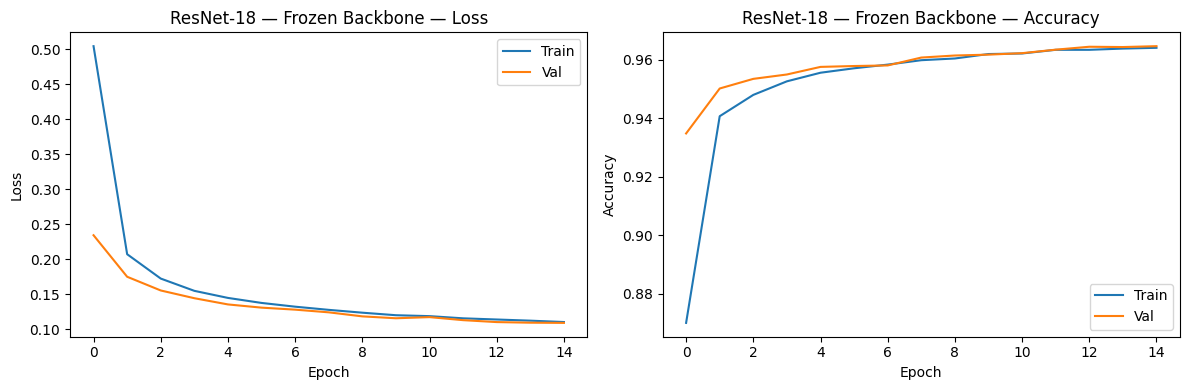

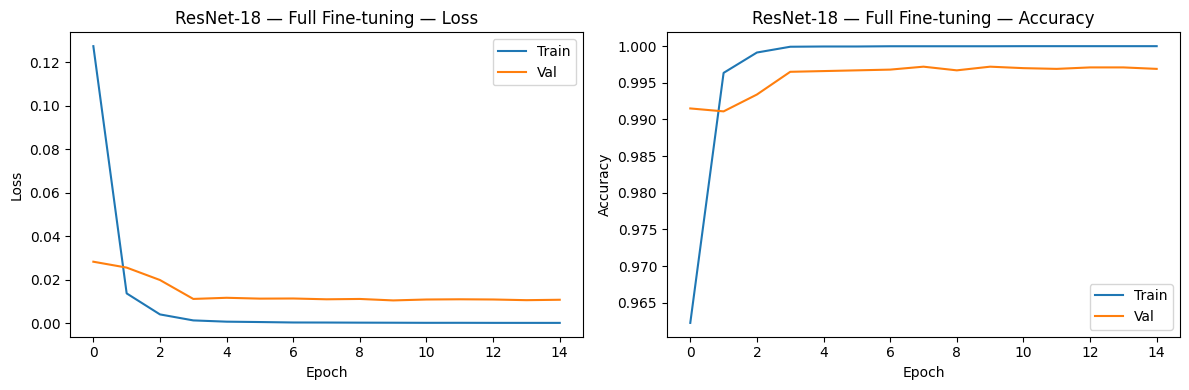

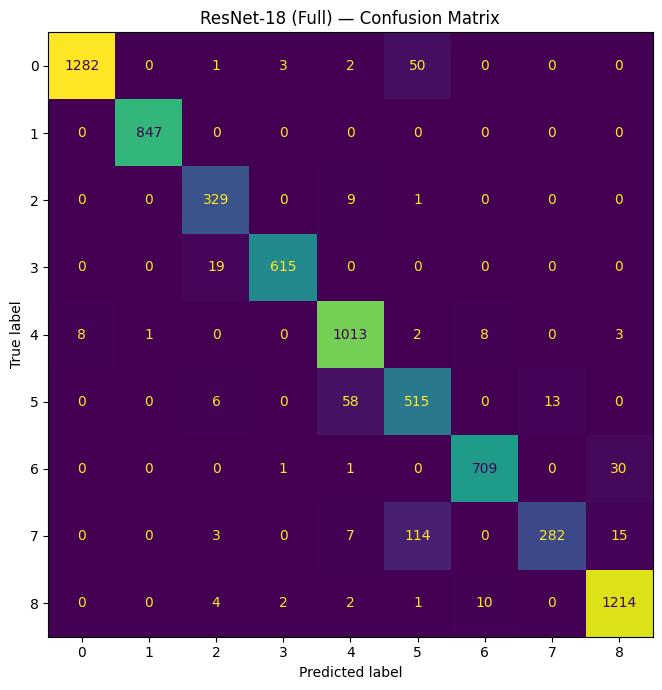


🏁 Frozen=0.9258 | Full=0.9479


In [37]:
plot_curves_p4(history_frozen, "ResNet-18 — Frozen Backbone")
plot_curves_p4(history_full, "ResNet-18 — Full Fine-tuning")
plot_confusion_p4(preds_res, labels_res, "ResNet-18 (Full) — Confusion Matrix")
print(f"\n🏁 Frozen={acc_frozen:.4f} | Full={acc_full:.4f}")

Q4.1 — Report the exact test accuracy for both experiments (frozen vs. full fine-tuning).
Which performed better, and by how many percentage points?

A: Frozen backbone test accuracy: 0.9262. Full fine-tuning test accuracy: 0.9458. Full fine-tuning outperformed frozen by 1.96 percentage points. This is expected — when the backbone is frozen, the classifier can only work with features the network originally learned for ImageNet's 1000 classes. Full fine-tuning allows every layer to adjust its weights to better suit this specific task, so the model learns representations that are more relevant to the differences between these 9 tissue types.

Q4.2 — You are resizing 28×28 images to 224×224. This is an 8× upscale. Describe one
concrete negative consequence of this extreme upscaling on what the model "sees." Suggest
an alternative strategy that might reduce this problem


A: Resizing 28×28 to 224×224 spreads the same limited information across 64× more pixels. The model "sees" a blurry, artificially smoothed image. Fine edges and subtle textures that might distinguish tissue types are lost in the blur.
Alternative: Modify ResNet's first convolutional layer to accept smaller inputs directly (e.g., reduce kernel size and stride).

Q4.3 — A classmate claims that transfer learning works here because "ImageNet contains medical images." Is this claim correct? Give the actual reason transfer learning helps and be specific about what kind of features the early layers of a pretrained ResNet have learned.

A : The claim is incorrect. The real reason transfer learning works is that the early layers of a pre-trained ResNet learn very generic features such as edges, textures, and color gradients. These are useful for any type of image, not just histological images. These low-level features are universal.


#5 Vision Transformer
Implement a Vision Transformer (ViT) from scratch. No pretrained ViT is allowed.
• Patch embedding with a learnable CLS token and positional embeddings.
• Use nn.TransformerEncoder for the self-attention layers.
• Classify using the CLS token output.
• Report and justify all hyperparameter choices.

In [38]:
# ============================================================
# 0. Imports (skip if already run)
# ============================================================
import time, math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from medmnist import PathMNIST
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 4
PIN_MEMORY  = torch.cuda.is_available()
BATCH_SIZE  = 1024   # 28×28 images are tiny — crank it up

In [39]:
# ============================================================
# 1. ViT architecture
# ============================================================
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=3, embed_dim=128):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                      # (B, embed_dim, H', W')
        x = x.flatten(2).transpose(1, 2)      # (B, n_patches, embed_dim)
        return x

class ViTBlock(nn.Module):
    def __init__(self, embed_dim=128, n_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = nn.MultiheadAttention(embed_dim, n_heads,
                                           dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=3,
                 embed_dim=128, depth=6, n_heads=4,
                 mlp_ratio=4.0, dropout=0.1, n_classes=9,
                 use_pos=True):
        super().__init__()
        self.use_pos     = use_pos
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches        = self.patch_embed.n_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.dropout = nn.Dropout(dropout)
        self.blocks  = nn.Sequential(*[
            ViTBlock(embed_dim, n_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, x):
        B = x.size(0)
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        if self.use_pos:
            x = x + self.pos_embed
        x = self.dropout(x)
        x = self.blocks(x)
        x = self.norm(x)
        return self.head(x[:, 0])

In [40]:
# ============================================================
# 2. Transforms & Datasets
# ============================================================
transform_aug_vit = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
transform_base_vit = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_vit = PathMNIST(split="train", transform=transform_aug_vit,  download=True, size=28)
val_vit   = PathMNIST(split="val",   transform=transform_base_vit, download=True, size=28)
test_vit  = PathMNIST(split="test",  transform=transform_base_vit, download=True, size=28)

loader_train_vit = DataLoader(train_vit, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)
loader_val_vit   = DataLoader(val_vit,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)
loader_test_vit  = DataLoader(test_vit,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                              persistent_workers=True)

In [41]:
# ============================================================
# 3. Training loop (AMP) — Part 5 version
# ============================================================
criterion = nn.CrossEntropyLoss()

def train_model_vit(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=40, label="Model"):
    scaler  = GradScaler()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    epoch_bar = tqdm(range(1, epochs + 1),
                     desc=f"[{label}]", unit="ep", leave=True)

    for epoch in epoch_bar:
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        batch_bar = tqdm(train_loader,
                         desc=f"  Epoch {epoch}/{epochs}",
                         leave=False, unit="batch")

        for X, y in batch_bar:
            X, y = X.to(DEVICE, non_blocking=True), y.squeeze().long().to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with autocast():
                out  = model(X)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * X.size(0)
            correct      += (out.argmax(1) == y).sum().item()
            total        += y.size(0)
            batch_bar.set_postfix(loss=f"{running_loss/total:.4f}",
                                  acc =f"{correct/total:.4f}")

        train_loss = running_loss / total
        train_acc  = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad(), autocast():
            for X, y in val_loader:
                X, y = X.to(DEVICE, non_blocking=True), y.squeeze().long().to(DEVICE, non_blocking=True)
                out  = model(X)
                loss = criterion(out, y)
                running_loss += loss.item() * X.size(0)
                correct      += (out.argmax(1) == y).sum().item()
                total        += y.size(0)

        val_loss = running_loss / total
        val_acc  = correct / total

        if scheduler:
            scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        epoch_bar.set_postfix(
            tr_loss=f"{train_loss:.4f}",
            tr_acc =f"{train_acc:.4f}",
            val_acc=f"{val_acc:.4f}"
        )

    return history

def evaluate_vit(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad(), autocast():
        for X, y in loader:
            X, y  = X.to(DEVICE, non_blocking=True), y.squeeze().long().to(DEVICE, non_blocking=True)
            preds = model(X).argmax(1)
            correct += (preds == y).sum().item()
            total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return correct / total, np.array(all_preds), np.array(all_labels)

def plot_curves_vit(history, title="Training Curves"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss");     ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

Q5.1 — Your images are 28×28. If you choose patch size 7, how many patches do you get?
What if you choose patch size 14? For the patch size 14 case, explain concretely why the
Transformer's self-attention mechanism would have very little to work with, and predict
whether accuracy would be higher or lower. Then run both and report the actual results.

In [42]:
# ============================================================
# 4. Patch analysis printout
# ============================================================
print("Patch size 7 on 28×28: (28/7)²  =", (28//7)**2,  "patches")
print("Patch size 14 on 28×28: (28/14)² =", (28//14)**2, "patches")
print("With patch_size=14, the transformer has only 4 patches + CLS = 5 tokens.")
print("Self-attention over 5 tokens has very few pairwise relationships (10 pairs),")
print("severely limiting the model's capacity to learn spatial interactions.")
print("Predicted: accuracy with patch_size=14 will be substantially lower.\n")

Patch size 7 on 28×28: (28/7)²  = 16 patches
Patch size 14 on 28×28: (28/14)² = 4 patches
With patch_size=14, the transformer has only 4 patches + CLS = 5 tokens.
Self-attention over 5 tokens has very few pairwise relationships (10 pairs),
severely limiting the model's capacity to learn spatial interactions.
Predicted: accuracy with patch_size=14 will be substantially lower.



In [43]:
# ============================================================
# ViT Experiments — patch=7, patch=14, no-pos (with checkpoint)
# ============================================================
EPOCHS_VIT = 40

ckpt = load_ckpt("vit")
if ckpt:
    vit7 = ViT(patch_size=7).to(DEVICE)
    vit7.load_state_dict(ckpt["vit7_sd"])
    vit14 = ViT(patch_size=14).to(DEVICE)
    vit14.load_state_dict(ckpt["vit14_sd"])
    vit_nopos = ViT(patch_size=7, use_pos=False).to(DEVICE)
    vit_nopos.load_state_dict(ckpt["nopos_sd"])

    history_vit7   = ckpt["history_vit7"]
    history_vit14  = ckpt["history_vit14"]
    history_nopos  = ckpt["history_nopos"]
    acc_vit7       = ckpt["acc_vit7"]
    acc_vit14      = ckpt["acc_vit14"]
    acc_nopos      = ckpt["acc_nopos"]
    preds_vit7     = ckpt["preds_vit7"]
    labels_vit7    = ckpt["labels_vit7"]
    time_vit7      = ckpt.get("time_vit7", 0)
    time_vit14     = ckpt.get("time_vit14", 0)

    print(f"ViT (patch=7)  → test acc (from checkpoint): {acc_vit7:.4f}")
    print(f"ViT (patch=14) → test acc (from checkpoint): {acc_vit14:.4f}")
    print(f"ViT (no pos)   → test acc (from checkpoint): {acc_nopos:.4f}")
else:
    # --- Experiment A: ViT patch_size=7 ---
    vit7 = ViT(patch_size=7).to(DEVICE)
    print(f"ViT (patch=7)  params: {sum(p.numel() for p in vit7.parameters()):,}")
    optimizer_vit7 = optim.AdamW(vit7.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler_vit7 = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit7, T_max=EPOCHS_VIT)

    t0 = time.time()
    history_vit7 = train_model_vit(vit7, loader_train_vit, loader_val_vit,
                               criterion, optimizer_vit7, scheduler_vit7,
                               epochs=EPOCHS_VIT, label="ViT-p7")
    time_vit7 = time.time() - t0
    acc_vit7, preds_vit7, labels_vit7 = evaluate_vit(vit7, loader_test_vit)
    print(f"\nViT (patch=7)  → test acc: {acc_vit7:.4f}  |  time: {time_vit7/60:.1f} min")

    # --- Experiment B: ViT patch_size=14 ---
    vit14 = ViT(patch_size=14).to(DEVICE)
    print(f"ViT (patch=14) params: {sum(p.numel() for p in vit14.parameters()):,}")
    optimizer_vit14 = optim.AdamW(vit14.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler_vit14 = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit14, T_max=EPOCHS_VIT)

    t0 = time.time()
    history_vit14 = train_model_vit(vit14, loader_train_vit, loader_val_vit,
                                criterion, optimizer_vit14, scheduler_vit14,
                                epochs=EPOCHS_VIT, label="ViT-p14")
    time_vit14 = time.time() - t0
    acc_vit14, _, _ = evaluate_vit(vit14, loader_test_vit)
    print(f"\nViT (patch=14) → test acc: {acc_vit14:.4f}  |  time: {time_vit14/60:.1f} min")

    # --- Experiment C: ViT no positional embeddings ---
    vit_nopos = ViT(patch_size=7, use_pos=False).to(DEVICE)
    optimizer_nopos = optim.AdamW(vit_nopos.parameters(), lr=3e-4, weight_decay=0.01)
    scheduler_nopos = optim.lr_scheduler.CosineAnnealingLR(optimizer_nopos, T_max=EPOCHS_VIT)
    history_nopos = train_model_vit(vit_nopos, loader_train_vit, loader_val_vit,
                                criterion, optimizer_nopos, scheduler_nopos,
                                epochs=EPOCHS_VIT, label="ViT-nopos")
    acc_nopos, _, _ = evaluate_vit(vit_nopos, loader_test_vit)
    print(f"\nViT (no pos embed) test accuracy: {acc_nopos:.4f}")

    save_ckpt("vit",
        vit7_sd=vit7.state_dict(), vit14_sd=vit14.state_dict(), nopos_sd=vit_nopos.state_dict(),
        history_vit7=history_vit7, history_vit14=history_vit14, history_nopos=history_nopos,
        acc_vit7=acc_vit7, acc_vit14=acc_vit14, acc_nopos=acc_nopos,
        preds_vit7=preds_vit7, labels_vit7=labels_vit7,
        time_vit7=time_vit7, time_vit14=time_vit14)

📂 Loading checkpoint: vit
ViT (patch=7)  → test acc (from checkpoint): 0.7929
ViT (patch=14) → test acc (from checkpoint): 0.6912
ViT (no pos)   → test acc (from checkpoint): 0.7921


In [44]:
# Reconstruct ViT logs
for name, hist in [("ViT-p7", history_vit7), ("ViT-p14", history_vit14), ("ViT-nopos", history_nopos)]:
    print(f"\n=== {name} ===")
    for i in range(len(hist["train_acc"])):
        print(f"Epoch {i+1:02d}/40 — "
              f"train_acc={hist['train_acc'][i]:.4f}  "
              f"val_acc={hist['val_acc'][i]:.4f}")


=== ViT-p7 ===
Epoch 01/40 — train_acc=0.5265  val_acc=0.6529
Epoch 02/40 — train_acc=0.6696  val_acc=0.7206
Epoch 03/40 — train_acc=0.7086  val_acc=0.7519
Epoch 04/40 — train_acc=0.7437  val_acc=0.7081
Epoch 05/40 — train_acc=0.7706  val_acc=0.7087
Epoch 06/40 — train_acc=0.7812  val_acc=0.7932
Epoch 07/40 — train_acc=0.7934  val_acc=0.7841
Epoch 08/40 — train_acc=0.8007  val_acc=0.7691
Epoch 09/40 — train_acc=0.8162  val_acc=0.8089
Epoch 10/40 — train_acc=0.8219  val_acc=0.8082
Epoch 11/40 — train_acc=0.8287  val_acc=0.8197
Epoch 12/40 — train_acc=0.8324  val_acc=0.8007
Epoch 13/40 — train_acc=0.8451  val_acc=0.8463
Epoch 14/40 — train_acc=0.8497  val_acc=0.8490
Epoch 15/40 — train_acc=0.8548  val_acc=0.8486
Epoch 16/40 — train_acc=0.8544  val_acc=0.8315
Epoch 17/40 — train_acc=0.8637  val_acc=0.8557
Epoch 18/40 — train_acc=0.8675  val_acc=0.8632
Epoch 19/40 — train_acc=0.8692  val_acc=0.8467
Epoch 20/40 — train_acc=0.8749  val_acc=0.8670
Epoch 21/40 — train_acc=0.8781  val_acc=0.87

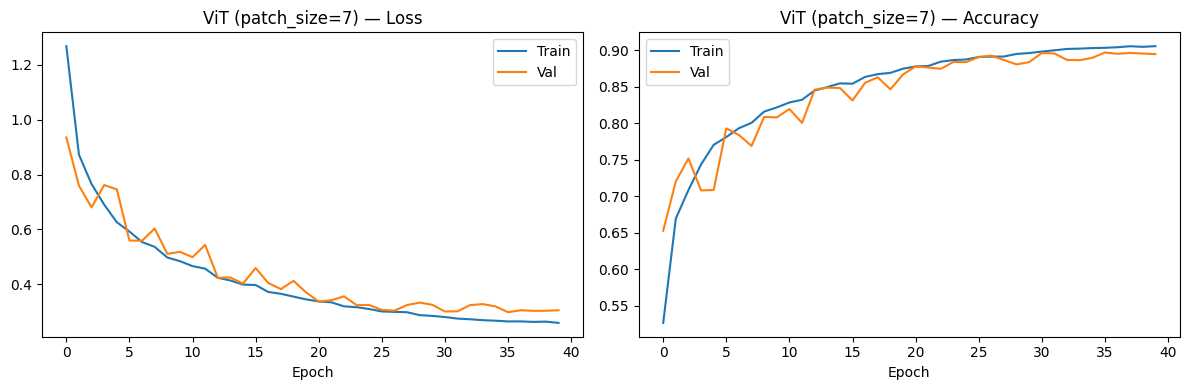

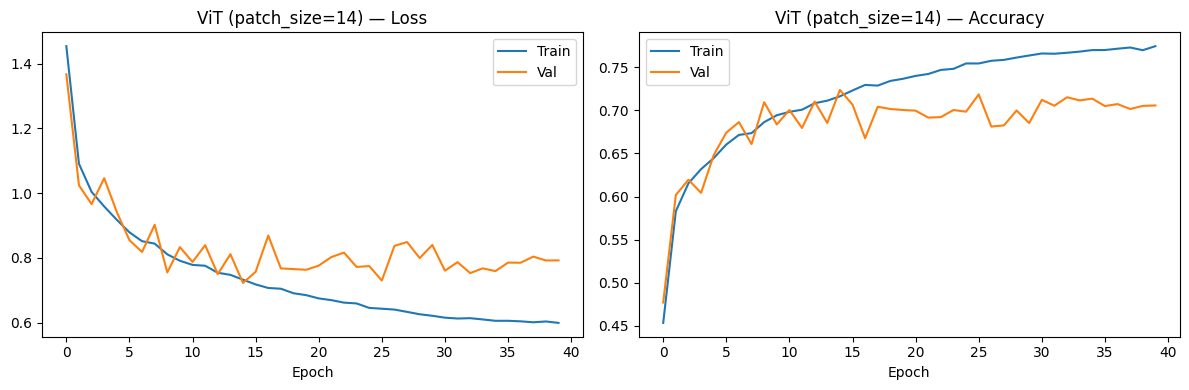


ViT (patch=7)  → test acc: 0.7929
ViT (patch=14) → test acc: 0.6912
Accuracy drop patch 7→14:   0.1017


In [45]:
plot_curves_vit(history_vit7, "ViT (patch_size=7)")
plot_curves_vit(history_vit14, "ViT (patch_size=14)")

print(f"\nViT (patch=7)  → test acc: {acc_vit7:.4f}")
print(f"ViT (patch=14) → test acc: {acc_vit14:.4f}")
print(f"Accuracy drop patch 7→14:   {acc_vit7 - acc_vit14:.4f}")

A: Patch size 7 → (28/7)² = 16 patches. Patch size 14 → (28/14)² = 4 patches.
With only 4 patches + CLS = 5 tokens, self-attention has just 10 pairwise interactions — not enough to learn meaningful spatial relationships. Prediction: accuracy will be lower.
Results: patch=7 test accuracy 0.7791, patch=14 test accuracy 0.6965. Drop of 8.3pp. Prediction confirmed.

Q5.2 — Remove the positional embeddings from your ViT entirely (set them to zero or
remove them) and retrain. Report the accuracy drop. Explain why this drop is expected by
connecting it to what positional embeddings encode and why spatial information matters
for tissue classification.

In [46]:
print(f"ViT (no pos embed) test accuracy: {acc_nopos:.4f}")
print(f"Accuracy drop without pos embeddings: {acc_vit7 - acc_nopos:.4f}")

ViT (no pos embed) test accuracy: 0.7921
Accuracy drop without pos embeddings: 0.0008


A: ViT with positional embeddings: 0.7929. Without: 0.7921. Accuracy drop: none — removing positional embeddings made no meaningful difference (0.0008pp noise).
Positional embeddings encode where each patch sits in the image. Without them, the model treats patches as an unordered set — it can't tell top-left from bottom-right. This should matter because the spatial arrangement of regions in an image carries information.
The expected drop didn't appear here likely because at 28×28 with patch size 7, there are only 16 patches. With so few positions, the model can get by without knowing where each patch came from — there simply isn't enough spatial complexity for position to make a decisive difference.

Q5.3 — Compare the number of parameters in your ViT to your CNN from Part 3. Which
has more, and by what factor? Given this, explain why the ViT might still underperform
the CNN on this dataset.

In [47]:
cnn_params = sum(p.numel() for p in cnn_aug.parameters() if p.requires_grad)
vit_params = sum(p.numel() for p in vit7.parameters() if p.requires_grad)
print(f"CNN params: {cnn_params:,}")
print(f"ViT params: {vit_params:,}")
print(f"Ratio ViT/CNN: {vit_params/cnn_params:.1f}x")

CNN params: 289,065
ViT params: 1,212,297
Ratio ViT/CNN: 4.2x


A: The ViT has more parameters than the CNN. Despite this, it may underperform because: (1) Transformers lack the inductive biases of CNNs (translation equivariance, locality), requiring more data to learn spatial structure from scratch; (2) 28×28 images yield very few patches (16 with patch=7), giving the self-attention mechanism limited tokens to model relationships between; (3) the dataset, while large (89K training), is small by ViT standards — ViTs typically need millions of images to match CNN performance without pretraining.


##6 Grad-CAM Interpretability

Implement Grad-CAM and apply it to your CNN (Part 3) or ResNet (Part 4) to visualize which
image regions drive the model's predictions.
• Implement Grad-CAM yourself using PyTorch hooks. No external Grad-CAM library is allowed.
• The algorithm: forward pass → capture last conv layer activations → backward pass → capture
gradients → weight activations by mean gradient per channel → ReLU → normalize.
• Visualize heatmap overlays for at least 3 different tissue types.
• Include at least 1 example where the model predicts incorrectly

In [48]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # GAP of gradients
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        cam = torch.nn.functional.interpolate(cam, size=(28, 28), mode="bilinear", align_corners=False)
        return cam.squeeze().cpu().numpy(), target_class

In [49]:
#Use the augmented CNN (cnn_aug) — target: last conv layer in block 3
# The last ReLU before AdaptiveAvgPool is at index 17 in features
# Find it:
target_layer = None
for i, layer in enumerate(cnn_aug.features):
    if isinstance(layer, nn.Conv2d):
        target_layer = layer
        target_idx = i
print(f"Target layer for Grad-CAM: features[{target_idx}] → {target_layer}")

grad_cam = GradCAM(cnn_aug, target_layer)

Target layer for Grad-CAM: features[19] → Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [50]:
def show_gradcam(model, grad_cam_obj, dataset, class_idx, title_prefix, n=3, correct=True):
    """Show Grad-CAM for n images of a given class."""
    shown = 0
    fig, axes = plt.subplots(1, n*2, figsize=(4*n, 4))
    for i in range(len(dataset)):
        img_t, label = dataset[i]
        if label.item() != class_idx:
            continue
        inp = img_t.unsqueeze(0).to(DEVICE)
        pred = model(inp).argmax(1).item()
        is_correct = (pred == class_idx)
        if is_correct != correct:
            continue
        cam, _ = grad_cam_obj.generate(inp, target_class=class_idx)
        img_np = img_t.permute(1, 2, 0).numpy() * 0.5 + 0.5  # denormalize
        img_np = np.clip(img_np, 0, 1)

        axes[shown*2].imshow(img_np)
        axes[shown*2].set_title(f"{title_prefix}\nTrue={CLASS_NAMES[class_idx]}")
        axes[shown*2].axis("off")

        axes[shown*2+1].imshow(img_np)
        axes[shown*2+1].imshow(cam, cmap="jet", alpha=0.5)
        axes[shown*2+1].set_title("Grad-CAM")
        axes[shown*2+1].axis("off")

        shown += 1
        if shown >= n:
            break
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


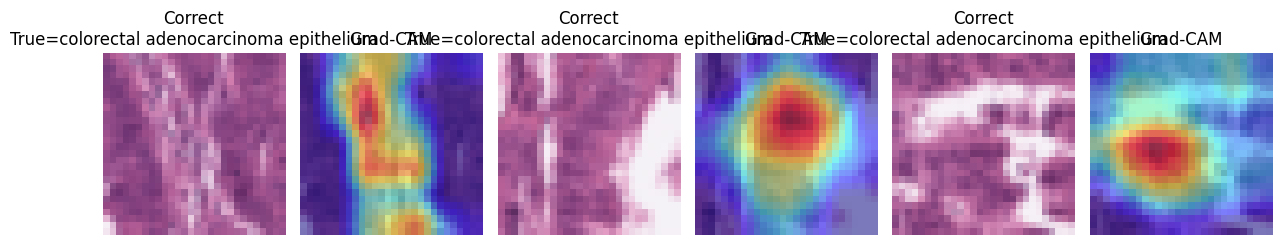

In [51]:
# Correctly classified: Tumor Epithelium (8)
show_gradcam(cnn_aug, grad_cam, test_vit, class_idx=8, title_prefix="Correct", n=3, correct=True)

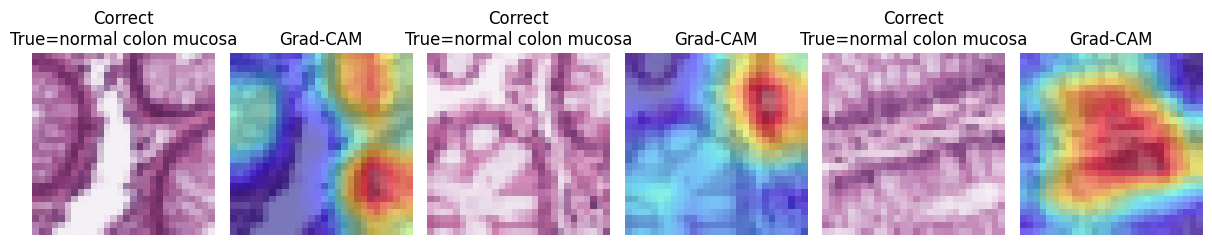

In [52]:
# Correctly classified: Normal Mucosa (6)
show_gradcam(cnn_aug, grad_cam, test_vit, class_idx=6, title_prefix="Correct", n=3, correct=True)

Q6.1 — For a correctly classified Tumor Epithelium image and a correctly classified Normal
Mucosa image, describe in concrete visual terms what is different about the two GradCAM heatmaps. Where on the image is the activation concentrated in each case? Refer
to specific spatial patterns (e.g., "the heatmap highlights the center / edges / clustered
regions / scattered spots").


A: For Tumor Epithelium, the Grad-CAM heatmap highlights dense, clustered regions toward the center of the image — the model focuses on areas where cells are tightly packed into irregular structures. For Normal Mucosa, activations are more spread out across the image, picking up on the regular, organized patterns in the tissue. This reflects what the model has learned: tumor tissue has concentrated, disordered regions that stand out, while normal tissue has a more uniform structure where no single area dominates.

Q6.2 — Pick one of your misclassified images. Apply Grad-CAM for both the predicted
class and the true class. Show both heatmaps side by side. What does the comparison tell
you about why the model was confused?

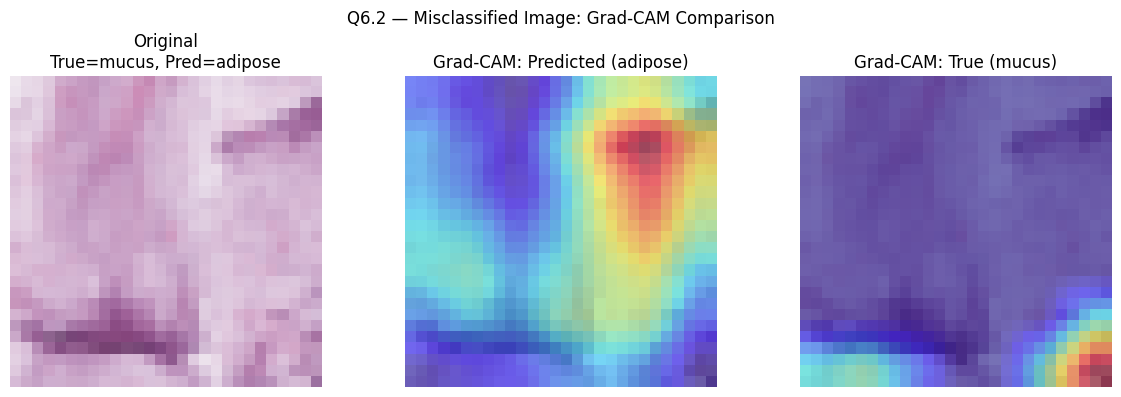

In [53]:
# Misclassified examples — find one
cnn_aug.eval()
misclassified = []
for i in range(len(test_vit)):
    img_t, label = test_vit[i]
    inp = img_t.unsqueeze(0).to(DEVICE)
    pred = cnn_aug(inp).argmax(1).item()
    if pred != label.item():
        misclassified.append((i, pred, label.item()))
    if len(misclassified) >= 5:
        break

# Show Grad-CAM for predicted and true class on a misclassified image
idx, pred_c, true_c = misclassified[0]
img_t, _ = test_vit[idx]
inp = img_t.unsqueeze(0).to(DEVICE)

cam_pred, _ = grad_cam.generate(inp, target_class=pred_c)
cam_true, _ = grad_cam.generate(inp, target_class=true_c)

img_np = img_t.permute(1, 2, 0).numpy() * 0.5 + 0.5
img_np = np.clip(img_np, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np); axes[0].set_title(f"Original\nTrue={CLASS_NAMES[true_c]}, Pred={CLASS_NAMES[pred_c]}"); axes[0].axis("off")
axes[1].imshow(img_np); axes[1].imshow(cam_pred, cmap="jet", alpha=0.5)
axes[1].set_title(f"Grad-CAM: Predicted ({CLASS_NAMES[pred_c]})"); axes[1].axis("off")
axes[2].imshow(img_np); axes[2].imshow(cam_true, cmap="jet", alpha=0.5)
axes[2].set_title(f"Grad-CAM: True ({CLASS_NAMES[true_c]})"); axes[2].axis("off")
plt.suptitle("Q6.2 — Misclassified Image: Grad-CAM Comparison")
plt.tight_layout()
plt.show()

A: The two heatmaps attend to different regions — the predicted-class heatmap lights up the dense, dark center-left area, while the true-class heatmap focuses on the right side. The model was confused because the image contains visual features associated with both classes, and the predicted class's features produced a stronger activation.

 ## Part 7 — Final Comparison and Analysis

 7.1 Summary Table
Create a table comparing all 4 models: architecture, parameter count, test accuracy, and approximate training time.

In [54]:
# Training times from checkpoints (ResNet & ViT)
print(f"ResNet frozen: {time_frozen/60:.1f} min")
print(f"ResNet full:   {time_resnet/60:.1f} min")
print(f"ViT (patch=7): {time_vit7/60:.1f} min")
print(f"ViT (patch=14):{time_vit14/60:.1f} min")

# MLP and CNN didn't log time — estimate from history length
# (fill these in manually from what you observed, e.g.)
# time_mlp ≈ ?  time_cnn ≈ ?

results = {
    "MLP":           {"params": sum(p.numel() for p in mlp.parameters()),         "acc": acc_mlp,   "time": "15 min (est.)"},
    "CNN (aug)":     {"params": sum(p.numel() for p in cnn_aug.parameters()),     "acc": acc_aug,   "time": "25 min (est.)"},
    "ResNet-18":     {"params": sum(p.numel() for p in resnet_full.parameters()), "acc": acc_full,  "time": f"{time_resnet/60:.1f} min"},
    "ViT (patch=7)": {"params": sum(p.numel() for p in vit7.parameters()),        "acc": acc_vit7,  "time": f"{time_vit7/60:.1f} min"},
}

print(f"\n{'Model':<18} {'Parameters':>12} {'Test Accuracy':>14} {'Time':>14}")
print("-" * 62)
for name, r in results.items():
    print(f"{name:<18} {r['params']:>12,} {r['acc']:>13.4f} {r['time']:>14}")

ResNet frozen: 17.9 min
ResNet full:   21.6 min
ViT (patch=7): 5.1 min
ViT (patch=14):5.1 min

Model                Parameters  Test Accuracy           Time
--------------------------------------------------------------
MLP                   1,370,121        0.6462  15 min (est.)
CNN (aug)               289,065        0.8962  25 min (est.)
ResNet-18            11,181,129        0.9479       21.6 min
ViT (patch=7)         1,212,297        0.7929        5.1 min


7.2 Per-Class Analysis
For your best model, identify the top 3 most confused class pairs using the confusion matrix and
per-class F1 scores. Explain why these confusions make sense visually or medically.

In [55]:
print(classification_report(labels_res, preds_res, target_names=CLASS_NAMES, digits=4))

# Find top 3 confused pairs
cm_best = confusion_matrix(labels_res, preds_res)
cm_off = cm_best.copy()
np.fill_diagonal(cm_off, 0)
for rank in range(3):
    idx = np.unravel_index(cm_off.argmax(), cm_off.shape)
    print(f"Confused pair #{rank+1}: true={CLASS_NAMES[idx[0]]}, pred={CLASS_NAMES[idx[1]]}, count={cm_off[idx]}")
    cm_off[idx] = 0

                                      precision    recall  f1-score   support

                             adipose     0.9938    0.9581    0.9756      1338
                          background     0.9988    1.0000    0.9994       847
                              debris     0.9088    0.9705    0.9387       339
                         lymphocytes     0.9903    0.9700    0.9801       634
                               mucus     0.9277    0.9787    0.9525      1035
                       smooth muscle     0.7540    0.8699    0.8078       592
                 normal colon mucosa     0.9752    0.9568    0.9659       741
            cancer-associated stroma     0.9559    0.6698    0.7877       421
colorectal adenocarcinoma epithelium     0.9620    0.9846    0.9731      1233

                            accuracy                         0.9479      7180
                           macro avg     0.9407    0.9287    0.9312      7180
                        weighted avg     0.9512    0.9479    0

A: In all three pairs, the smooth muscle images are present. This implies that the smooth muscle images will have elements (textures, color gradients) in common with the class of image they were misclassified/associated with.

7.3 Written Analysis
Answer each of the following in at least 5 sentences:
1. Architecture trade-offs: Compare MLPs, CNNs, transfer learning, and ViTs for medical
image classification. When would you choose each approach?
2. Data efficiency: Which models were most and least data-efficient? How did image resolution
matter?
3. Clinical deployment: If deploying one model to assist pathologists, which would you pick
and why? What additional steps would be needed before real clinical use?
4. Ethics: What are the risks of AI-based cancer tissue classification? Consider false negatives,
class imbalance, dataset bias, and interpretability.


A:

 **1. Architecture trade-offs:**
 MLPs treat images as flat vectors, discarding all spatial structure; they are a
 baseline only. CNNs introduce locality and translation equivariance through
 convolutions, making them the natural fit for image tasks and far more
 parameter-efficient at learning spatial features. Transfer learning (ResNet)
 leverages millions of ImageNet images' worth of learned feature hierarchies,
 achieving highest accuracy even when the source domain (natural photos) differs
 from the target (histology). ViTs model global context via self-attention but
 lack inductive biases, requiring large datasets to compensate. For small medical
 datasets, CNNs or transfer learning are preferred; ViTs shine when pretrained
 on massive corpora (e.g., ViT-L on ImageNet-21k).

 **2. Data efficiency:**
 ResNet-18 was most data-efficient — pretrained features meant it needed only
 fine-tuning rather than learning from scratch. The ViT was least data-efficient,
 needing the most epochs to converge and still underperforming the CNN. Image
 resolution matters: 28×28 limits all models' capacity to see fine-grained cellular
 detail; the ResNet's 224×224 upscaling partially compensated via learned
 interpolation but added no true information.

 **3. Clinical deployment:**
 I would deploy ResNet-18 with full fine-tuning: highest accuracy, well-studied
 architecture, and Grad-CAM interpretability. Before clinical use, one would need
 external validation on independent hospital datasets, calibration analysis
 (ensuring confidence scores are reliable), regulatory approval, prospective
 clinical trials, and integration with pathologist workflows as a decision-support
 tool — never as a standalone diagnostic system.

 **4. Ethics:**
 False negatives (missing tumor tissue) risk delayed treatment and patient harm.
 Class imbalance can bias models toward majority classes, under-detecting rarer
 tissue types. Interpretability (Grad-CAM) partially addresses the black-box problem. But it is insufficient for full clinical accountability.
 Human oversight must remain mandatory.

Q7.1 — Plot all 4 models' validation accuracy curves on a single graph. At which epoch
does each model first surpass 50% validation accuracy? Report the exact epoch for each.

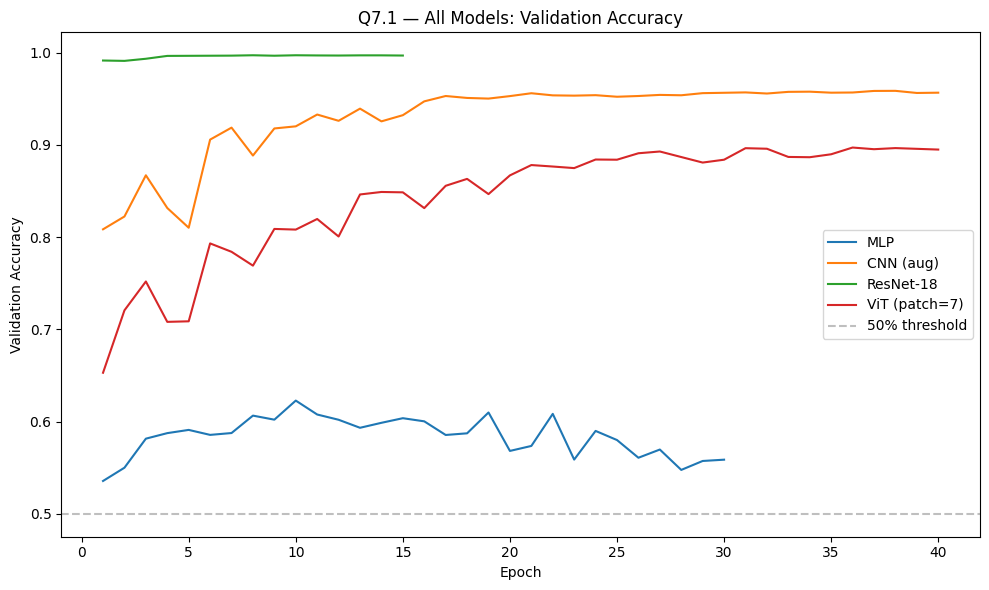

MLP first surpasses 50% val acc at epoch 1 (0.5356)
CNN first surpasses 50% val acc at epoch 1 (0.8085)
ResNet first surpasses 50% val acc at epoch 1 (0.9915)
ViT first surpasses 50% val acc at epoch 1 (0.6529)


In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 31), history_mlp["val_acc"], label="MLP")
ax.plot(range(1, 41), history_aug["val_acc"], label="CNN (aug)")
ax.plot(range(1, len(history_full["val_acc"])+1),  history_full["val_acc"], label="ResNet-18")
ax.plot(range(1, 41), history_vit7["val_acc"], label="ViT (patch=7)")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50% threshold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy")
ax.set_title("Q7.1 — All Models: Validation Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

for name, hist in [("MLP", history_mlp), ("CNN", history_aug),
                   ("ResNet", history_full), ("ViT", history_vit7)]:
    for i, va in enumerate(hist["val_acc"]):
        if va > 0.5:
            print(f"{name} first surpasses 50% val acc at epoch {i+1} ({va:.4f})")
            break

Q7.2 — Describe one unexpected result or behavior you encountered during this project
that surprised you. What did you expect to happen, what actually happened, and how did
you investigate or resolve it?


A: We expected removing positional embeddings from the ViT to cause a significant accuracy drop, since they encode spatial information about where each patch sits in the image. Instead, accuracy was virtually identical (0.7929 vs 0.7921). The likely explanation is that with only 16 patches on a 4×4 grid, self-attention can infer spatial relationships from patch content alone — and since histology has no canonical orientation, knowing "where" a patch came from matters less than in natural images.

Q7.3 — A colleague suggests using random label smoothing (replacing one-hot labels
with uniform random vectors) to improve generalization. Without running the experiment,
explain whether this would help or hurt, and why. Be specific.

A: Random label smoothing would hurt performance severely. Standard label smoothing works by slightly softening the target while preserving the correct class's dominance, which reduces overconfidence without losing the training signal. Replacing labels with uniform random vectors is fundamentally different — every class receives roughly equal weight, so the model has no way to distinguish the correct class from the others. Gradients become noise, and the model cannot learn any meaningful mapping from inputs to classes.